In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from collections import deque, defaultdict
from utils import lineage_name_mapping, load_json, bidict
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
import seaborn as sns
from pareto_core import LineageOptimization, LineageTree
from tqdm import tqdm

In [ ]:
main_path = "output/internal_opt/embryo1/10_pca_255_l2"
lineage_cost = np.load(main_path + "/lineage_costs.npz")
pareto_result = pd.read_csv(main_path + "/pareto_comparison.csv")
pareto_df_terminal_only_kd_internal = pd.read_csv(main_path + "/pareto_terminal_only_kd_internal.tsv", sep='\t')
pareto_df_terminal_only_kd_internal_no_exp_replacement = pd.read_csv(main_path + "/pareto_terminal_only_kd_internal_no_exp_replacement.tsv", sep='\t')

In [5]:
pareto_xyz_cost_list_by_layer = pareto_result["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = pareto_result["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = pareto_result["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = pareto_result["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = pareto_result["Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = pareto_result["Top-Down Rebuild (Hard Depth Cutoff) Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = pareto_result["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = pareto_result["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
pareto_xyz_cost_list_mst = pareto_result["MST Based Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_mst = pareto_result["MST Based Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['xyz_cost'].tolist()
pareto_exp_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['exp_cost'].tolist()
pareto_internal_selection_count_list_terminal_only_kd_internal = [eval(s) for s in pareto_df_terminal_only_kd_internal['internal_selection_count'].tolist()]
pareto_xyz_cost_list_terminal_only_kd_internal_no_replacement = pareto_df_terminal_only_kd_internal_no_exp_replacement['xyz_cost'].tolist()
pareto_exp_cost_list_terminal_only_kd_internal_no_replacement = pareto_df_terminal_only_kd_internal_no_exp_replacement['exp_cost'].tolist()

In [8]:
lineage_cost['xyz_cost'], lineage_cost['exp_cost']

(array(4465.54761259), array(93660.68405075))

In [25]:
subtree_paths = ["output/internal_opt/embryo1/10_pca_255_l2/",
                "output/internal_opt/embryo1/10_pca_255_l2/ABa",
                 "output/internal_opt/embryo1/10_pca_255_l2/ABp",
                 "output/internal_opt/embryo1/10_pca_255_l2/P1"]

tree_names = ["Full Lineage", "ABa Subtree", "ABp Subtree", "P1 Subtree"]

colors = sns.color_palette("Set2", len(subtree_paths))

lineage_costs_list = []
pareto_fronts = []

for path in subtree_paths:
    lineage_costs = np.load(path + "/lineage_costs.npz")
    pareto_results = pd.read_csv(path + "/pareto_comparison.csv")
    pareto_xyz_cost_list_by_layer = pareto_results["Bottom-up By Layer XYZ Cost"].tolist()
    pareto_exp_cost_list_by_layer = pareto_results["Bottom-up By Layer Exp Cost"].tolist()
    # normalize pareto_xyz_cost_list_by_layer and pareto_exp_cost_list_by_layer to [0,1] separately
    pareto_xyz_cost_normalized = (pareto_xyz_cost_list_by_layer - np.min(pareto_xyz_cost_list_by_layer)) / (np.max(pareto_xyz_cost_list_by_layer) - np.min(pareto_xyz_cost_list_by_layer))
    pareto_exp_cost_normalized = (pareto_exp_cost_list_by_layer - np.min(pareto_exp_cost_list_by_layer)) / (np.max(pareto_exp_cost_list_by_layer) - np.min(pareto_exp_cost_list_by_layer))
    # normalize lineage costs using the pareto normalization parameters
    lineage_xyz_cost_normalized = (lineage_costs['xyz_cost'] - np.min(pareto_xyz_cost_list_by_layer)) / (np.max(pareto_xyz_cost_list_by_layer) - np.min(pareto_xyz_cost_list_by_layer))
    lineage_exp_cost_normalized = (lineage_costs['exp_cost'] - np.min(pareto_exp_cost_list_by_layer)) / (np.max(pareto_exp_cost_list_by_layer) - np.min(pareto_exp_cost_list_by_layer))
    lineage_costs_list.append((lineage_xyz_cost_normalized, lineage_exp_cost_normalized))
    pareto_fronts.append((pareto_xyz_cost_normalized, pareto_exp_cost_normalized))


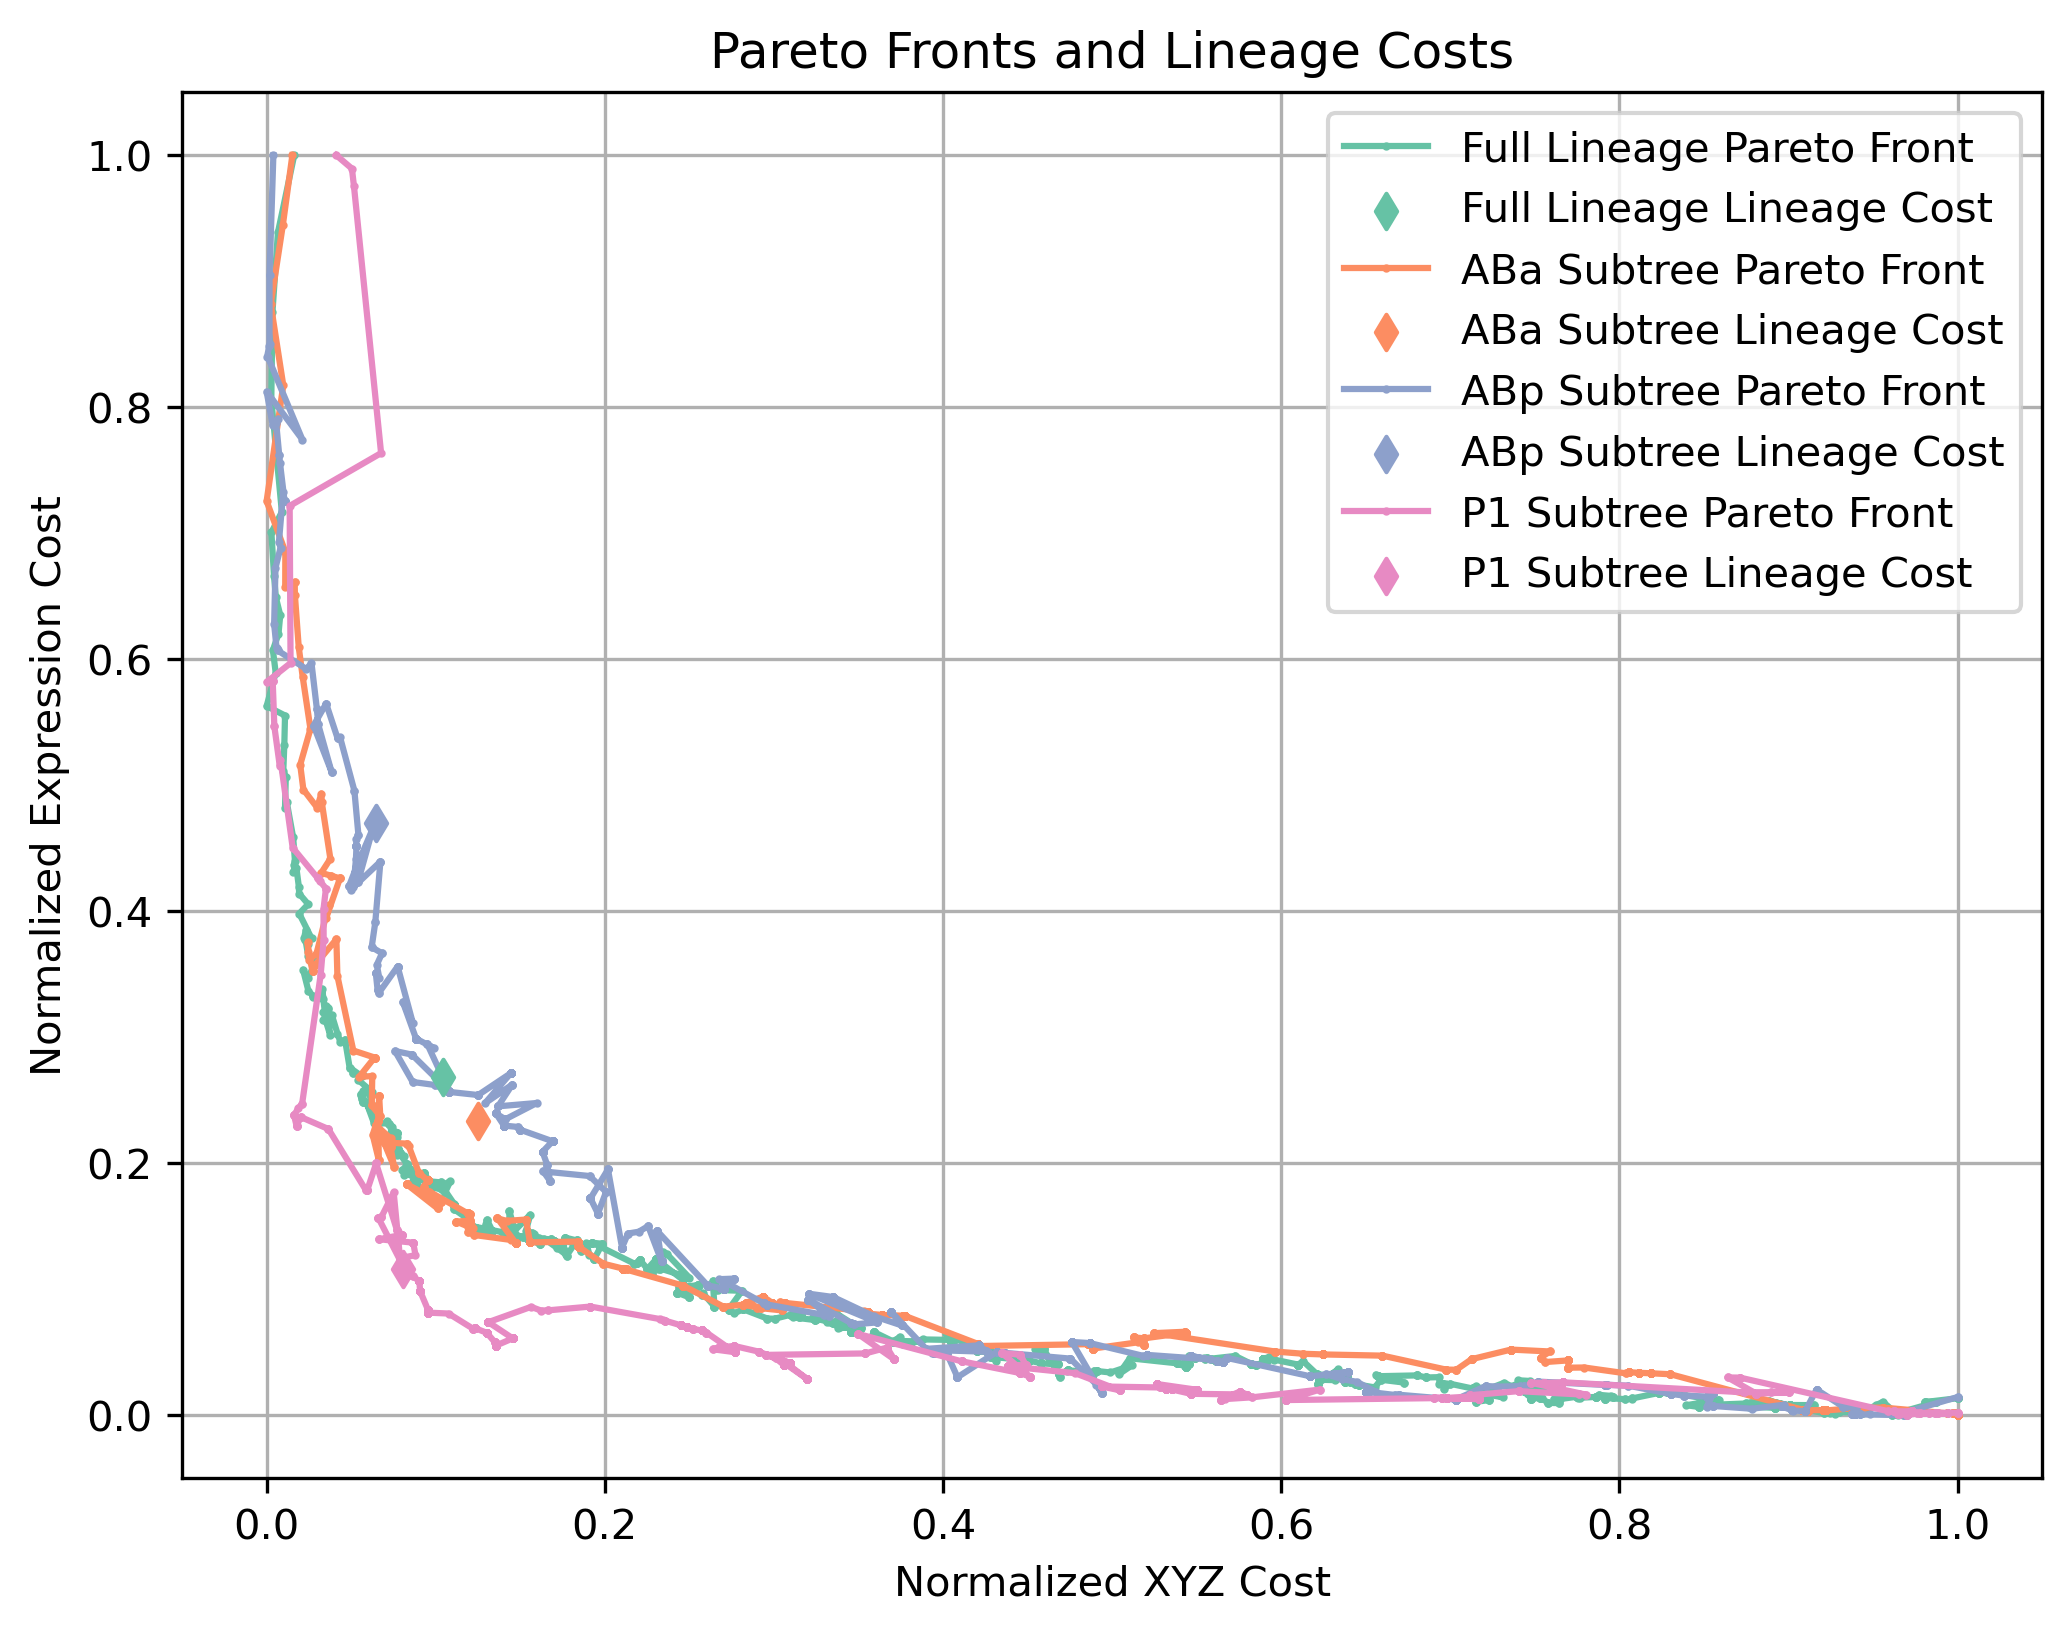

In [26]:
# plot all pareto fronts and lineage costs in the same figure
plt.figure(figsize=(8,6))
for i in range(len(subtree_paths)):
    plt.plot(pareto_fronts[i][0], pareto_fronts[i][1], label=tree_names[i] + " Pareto Front", color=colors[i], marker='o', linestyle='-', markersize=1)
    plt.scatter(lineage_costs_list[i][0], lineage_costs_list[i][1], label=tree_names[i] + " Lineage Cost", color=colors[i], marker='d', zorder=5)
plt.xlabel("Normalized XYZ Cost")
plt.ylabel("Normalized Expression Cost")
plt.title("Pareto Fronts and Lineage Costs")
plt.legend()
plt.grid()
plt.show()